Setup and Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files



In [2]:
# upload your local csv file here
uploaded = files.upload()

Saving SpotifyFeatures.csv to SpotifyFeatures.csv


In [3]:
df = pd.read_csv('SpotifyFeatures.csv')
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Shape: (232725, 18)

Column Names:
 ['genre', 'artist_name', 'track_name', 'track_id', 'popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence']

Missing Values:
 genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


Data Cleaning

In [4]:

# Drop the 1 missing track_name row
df = df.dropna(subset=['track_name'])

# Drop duplicate tracks (same track_id)
df = df.drop_duplicates(subset=['track_id'])

# Check basic stats
print("Shape after cleaning:", df.shape)
print("\nPopularity Stats:")
print(df['popularity'].describe())

Shape after cleaning: (176773, 18)

Popularity Stats:
count    176773.000000
mean         36.273119
std          17.391056
min           0.000000
25%          25.000000
50%          37.000000
75%          49.000000
max         100.000000
Name: popularity, dtype: float64


Exploratory Data Analysis

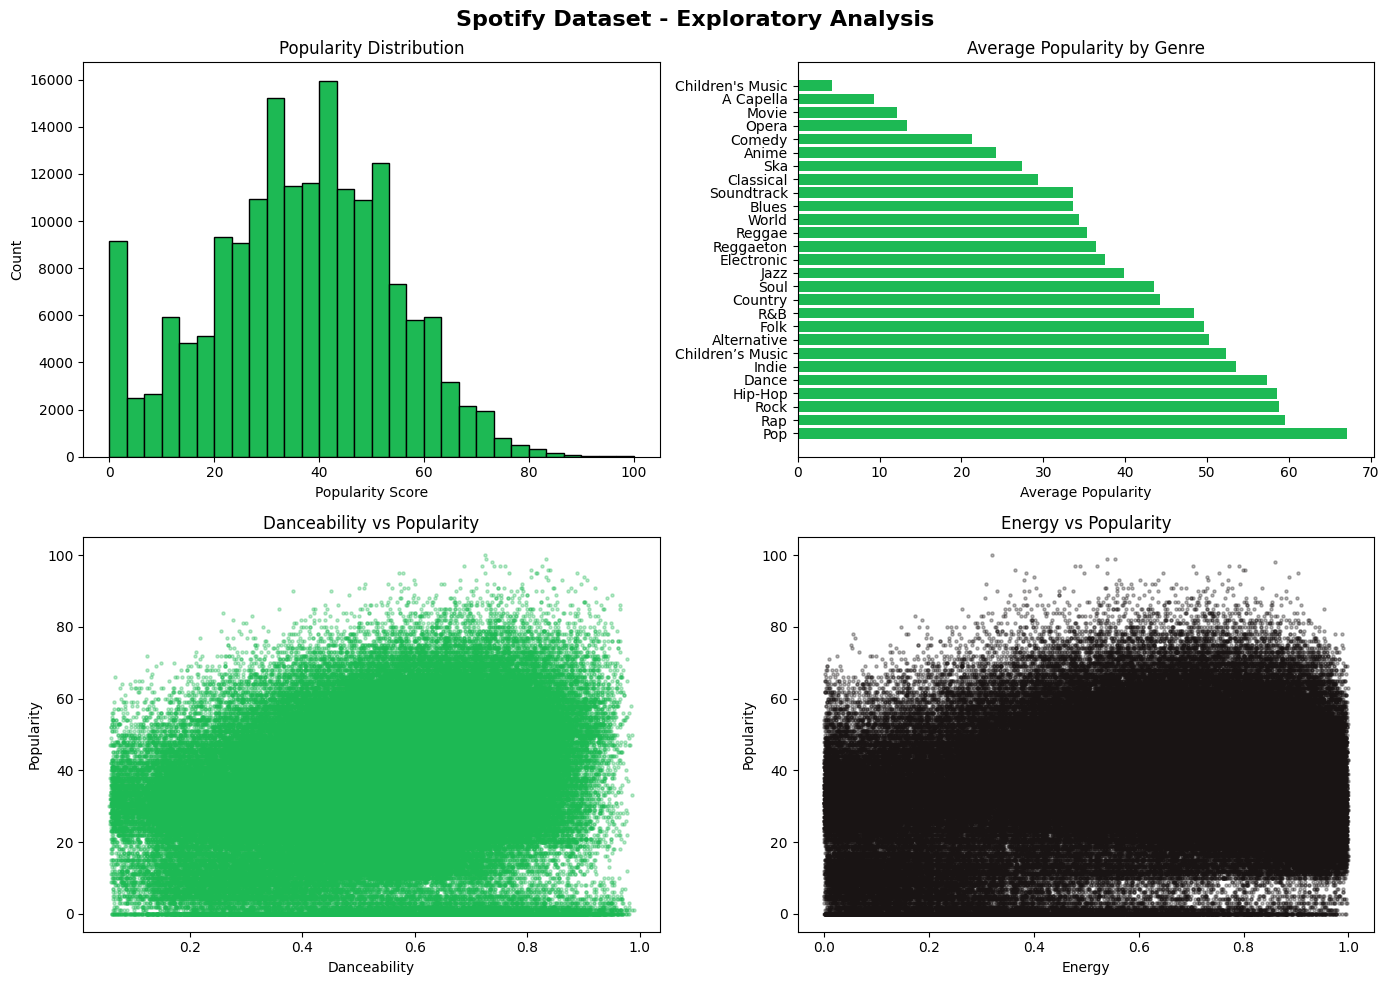

In [5]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Spotify Dataset - Exploratory Analysis', fontsize=16, fontweight='bold')

# 1. Popularity Distribution
axes[0,0].hist(df['popularity'], bins=30, color='#1DB954', edgecolor='black')
axes[0,0].set_title('Popularity Distribution')
axes[0,0].set_xlabel('Popularity Score')
axes[0,0].set_ylabel('Count')

# 2. Average Popularity by Genre
genre_pop = df.groupby('genre')['popularity'].mean().sort_values(ascending=False)
axes[0,1].barh(genre_pop.index, genre_pop.values, color='#1DB954')
axes[0,1].set_title('Average Popularity by Genre')
axes[0,1].set_xlabel('Average Popularity')

# 3. Danceability vs Popularity
axes[1,0].scatter(df['danceability'], df['popularity'], alpha=0.3, color='#1DB954', s=5)
axes[1,0].set_title('Danceability vs Popularity')
axes[1,0].set_xlabel('Danceability')
axes[1,0].set_ylabel('Popularity')

# 4. Energy vs Popularity
axes[1,1].scatter(df['energy'], df['popularity'], alpha=0.3, color='#191414', s=5)
axes[1,1].set_title('Energy vs Popularity')
axes[1,1].set_xlabel('Energy')
axes[1,1].set_ylabel('Popularity')

plt.tight_layout()
plt.show()

Correlation Heatmap

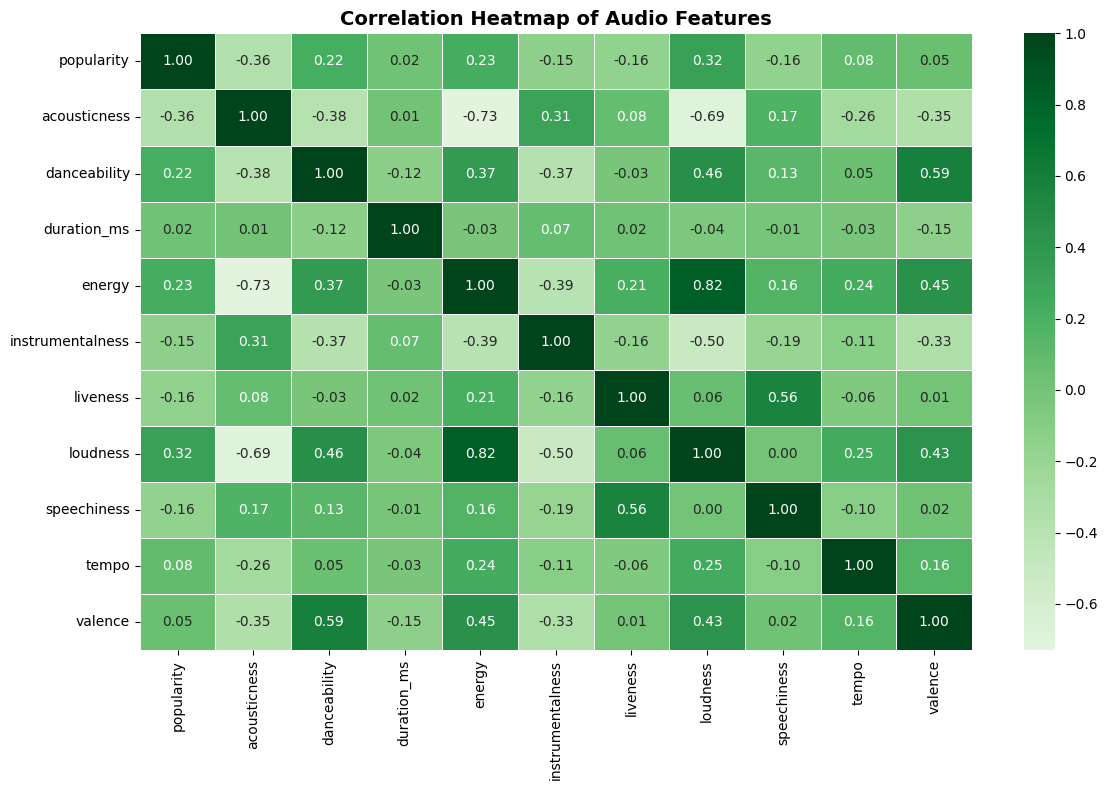

In [6]:
# Select only numeric columns
numeric_cols = ['popularity', 'acousticness', 'danceability', 'duration_ms',
                'energy', 'instrumentalness', 'liveness', 'loudness',
                'speechiness', 'tempo', 'valence']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='Greens',
            center=0,
            linewidths=0.5)
plt.title('Correlation Heatmap of Audio Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Linear regression

=== Linear Regression Results ===
RMSE: 15.57
R² Score: 0.2010

Feature Coefficients:
         Feature  Coefficient
    danceability    15.902146
    mode_encoded     1.920831
    time_encoded     1.110249
        loudness     0.526280
     key_encoded     0.035797
     duration_ms     0.000003
           tempo    -0.003170
instrumentalness    -2.240803
          energy    -2.667628
     speechiness    -7.632226
        liveness    -7.952562
    acousticness   -10.338935
         valence   -13.179344


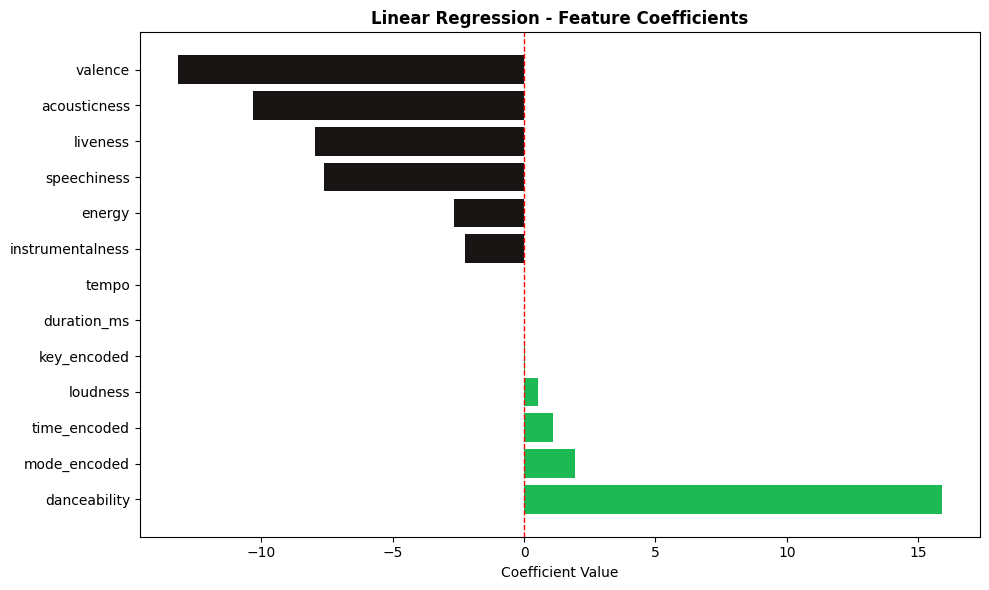

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# --- Prepare Features ---
# Encode categorical columns
le_key = LabelEncoder()
le_mode = LabelEncoder()
le_time = LabelEncoder()

df['key_encoded'] = le_key.fit_transform(df['key'])
df['mode_encoded'] = le_mode.fit_transform(df['mode'])
df['time_encoded'] = le_time.fit_transform(df['time_signature'])

# Define features and target
features = ['acousticness', 'danceability', 'duration_ms', 'energy',
            'instrumentalness', 'liveness', 'loudness', 'speechiness',
            'tempo', 'valence', 'key_encoded', 'mode_encoded', 'time_encoded']

X = df[features]
y = df['popularity']

# --- Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Train Model ---
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# --- Evaluate ---
y_pred = model_lr.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Linear Regression Results ===")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# --- Feature Importance ---
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model_lr.coef_
}).sort_values('Coefficient', ascending=False)

print("\nFeature Coefficients:")
print(coef_df.to_string(index=False))

# --- Plot Coefficients ---
plt.figure(figsize=(10, 6))
colors = ['#1DB954' if c > 0 else '#191414' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.title('Linear Regression - Feature Coefficients', fontweight='bold')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

Logistic repression (Hit vs Non-Hit)

Hit vs Non-Hit Distribution:
hit
0    136070
1     40703
Name: count, dtype: int64

Hit %: 23.0%

=== Logistic Regression Results ===
Accuracy:  0.6197
Precision: 0.3505
Recall:    0.7515
F1-Score:  0.4780


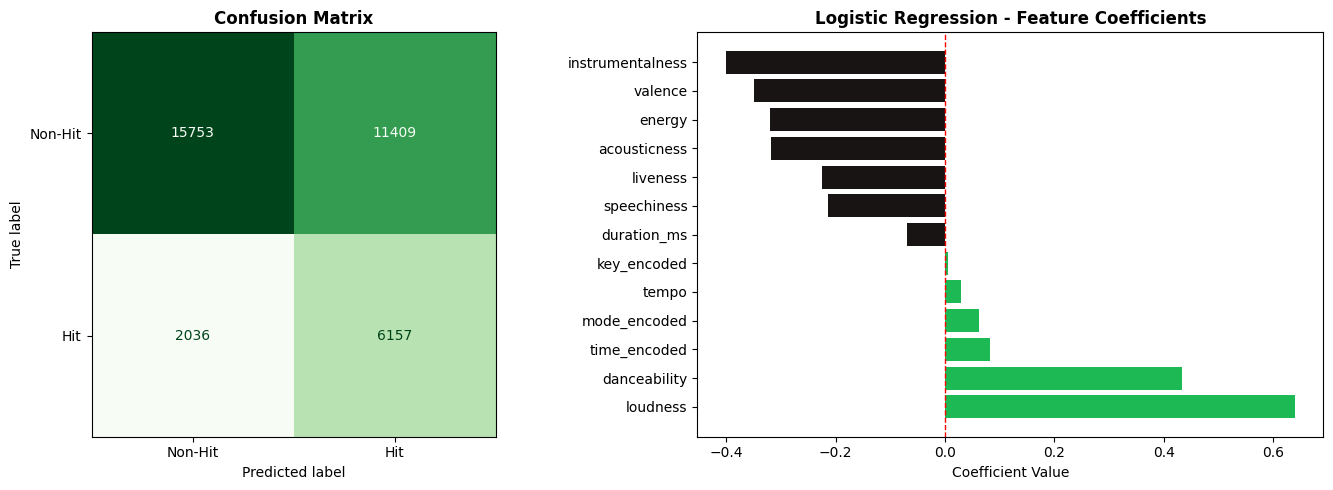

In [8]:
# (Revised - balanced threshold)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

# --- Revised threshold: 50 instead of 70 ---
df['hit'] = (df['popularity'] >= 50).astype(int)
print("Hit vs Non-Hit Distribution:")
print(df['hit'].value_counts())
print(f"\nHit %: {df['hit'].mean()*100:.1f}%")

# --- Prepare Features ---
X = df[features]
y = df['hit']

# --- Scale Features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# --- Train Model with class_weight balanced ---
model_log = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_log.fit(X_train, y_train)

# --- Evaluate ---
y_pred = model_log.predict(X_test)

print("\n=== Logistic Regression Results ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")

# --- Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Hit', 'Hit'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix', fontweight='bold')

# --- Feature Coefficients ---
coef_log = pd.DataFrame({
    'Feature': features,
    'Coefficient': model_log.coef_[0]
}).sort_values('Coefficient', ascending=False)

colors = ['#1DB954' if c > 0 else '#191414' for c in coef_log['Coefficient']]
axes[1].barh(coef_log['Feature'], coef_log['Coefficient'], color=colors)
axes[1].set_title('Logistic Regression - Feature Coefficients', fontweight='bold')
axes[1].set_xlabel('Coefficient Value')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

K means Clustering (STG Segmentation)

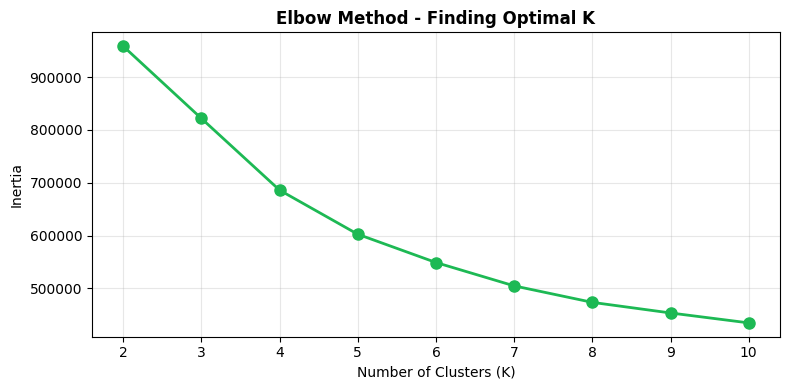

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Prepare Features for Clustering ---
cluster_features = ['danceability', 'energy', 'acousticness',
                    'instrumentalness', 'valence', 'tempo',
                    'loudness', 'speechiness']

X_cluster = df[cluster_features].copy()

# --- Scale Features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# --- Find Optimal K using Elbow Method ---
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, 'o-', color='#1DB954', linewidth=2, markersize=8)
plt.title('Elbow Method - Finding Optimal K', fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

=== Cluster Profiles ===
         danceability  energy  acousticness  instrumentalness  valence   tempo  loudness  speechiness  popularity
cluster                                                                                                          
0                0.70    0.67          0.22              0.07     0.66  108.96     -7.24         0.10       40.65
1                0.29    0.17          0.84              0.78     0.16  102.51    -20.97         0.05       28.33
2                0.47    0.30          0.76              0.06     0.32  110.45    -13.08         0.06       32.22
3                0.57    0.66          0.79              0.00     0.41   97.75    -12.04         0.89       20.95
4                0.50    0.76          0.11              0.11     0.43  143.17     -6.07         0.09       40.55


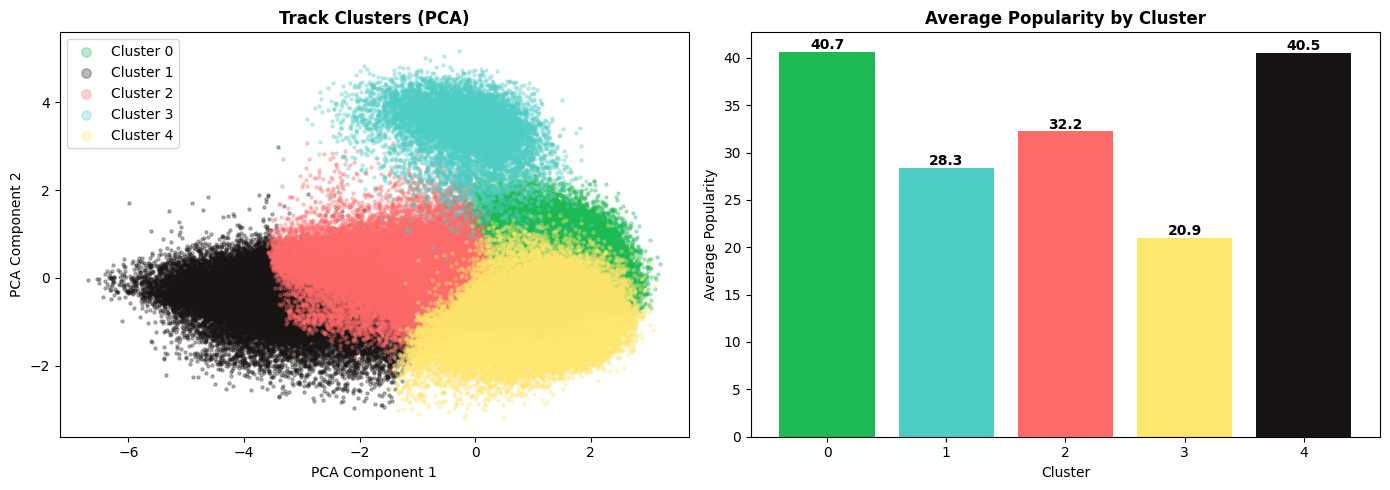

In [10]:
#  K-Means with K=5
# --- Train Final Model ---
km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

# --- PCA for Visualization ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- Cluster Profile ---
cluster_profile = df.groupby('cluster')[cluster_features + ['popularity']].mean().round(2)
print("=== Cluster Profiles ===")
print(cluster_profile.to_string())

# --- Plot 1: PCA Scatter ---
colors = ['#1DB954', '#191414', '#FF6B6B', '#4ECDC4', '#FFE66D']
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for i in range(5):
    mask = df['cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=f'Cluster {i}', alpha=0.3, s=5)
plt.title('Track Clusters (PCA)', fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(markerscale=3)

# --- Plot 2: Avg Popularity per Cluster ---
plt.subplot(1, 2, 2)
cluster_pop = df.groupby('cluster')['popularity'].mean().sort_values(ascending=False)
plt.bar(cluster_pop.index, cluster_pop.values, color=colors)
plt.title('Average Popularity by Cluster', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Average Popularity')
for i, v in enumerate(cluster_pop.values):
    plt.text(cluster_pop.index[i], v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Project Summary

In [11]:
# Project Summary
summary = """
╔══════════════════════════════════════════════════════════════════╗
║         SPOTIFY MARKETING ANALYTICS - PROJECT SUMMARY           ║
╚══════════════════════════════════════════════════════════════════╝

DATASET
-------
- Source:    Kaggle - Ultimate Spotify Tracks DB (Zaheen Hamidani)
- Tracks:    176,773 (after cleaning)
- Features:  18 columns (audio features + metadata)
- Target:    popularity (0-100)

──────────────────────────────────────────────────────────────────
ANALYSIS 1 — LINEAR REGRESSION (Predict Popularity Score)
──────────────────────────────────────────────────────────────────
- RMSE:        15.57  (avg prediction error out of 100)
- R² Score:    0.20   (model explains 20% of popularity variance)

Top Positive Drivers:   danceability (+15.9), mode (+1.9)
Top Negative Drivers:   valence (-13.2), acousticness (-10.3)

Insight: Audio features alone explain 20% of popularity.
         Non-audio factors (artist fame, marketing, playlist
         placement) account for the remaining 80%.

──────────────────────────────────────────────────────────────────
ANALYSIS 2 — LOGISTIC REGRESSION (Hit vs Non-Hit, threshold = 50)
──────────────────────────────────────────────────────────────────
- Accuracy:    61.97%
- Precision:   35.05%
- Recall:      75.15%  ← catches 3 out of 4 actual hits
- F1-Score:    0.478

Top Hit Predictors:     loudness (+0.65), danceability (+0.43)
Top Non-Hit Predictors: instrumentalness (-0.42), valence (-0.35)

Insight: The model is strong at catching real hits (recall 75%)
         making it useful for filtering promising tracks early.

──────────────────────────────────────────────────────────────────
ANALYSIS 3 — K-MEANS CLUSTERING (STG Segmentation, K=5)
──────────────────────────────────────────────────────────────────
  Cluster 0 | Feel-Good Dance       | Popularity: 40.7 ⭐ highest
  Cluster 4 | High Energy Electronic| Popularity: 40.5 ⭐ joint top
  Cluster 2 | Soft Acoustic Pop     | Popularity: 32.2
  Cluster 1 | Ambient Instrumental  | Popularity: 28.3
  Cluster 3 | Spoken Word / Live    | Popularity: 20.9 lowest

Insight: Target Clusters 0 and 4 for marketing campaigns.
         Loud, danceable, energetic tracks consistently
         outperform all other audio profiles.

──────────────────────────────────────────────────────────────────
OVERALL FINDING
──────────────────────────────────────────────────────────────────
  The most commercially successful Spotify tracks share three
  core audio traits: high danceability, high loudness, and
  high energy. These features appear as top predictors across
  all three analyses, making them reliable signals for
  marketing and A&R decision making.

  As the course progresses, additional methods such as Random
  Forest, Ridge/Lasso Regression, and advanced clustering
  techniques will be incorporated to further improve results.
╚══════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════════╗
║         SPOTIFY MARKETING ANALYTICS - PROJECT SUMMARY           ║
╚══════════════════════════════════════════════════════════════════╝

DATASET
-------
- Source:    Kaggle - Ultimate Spotify Tracks DB (Zaheen Hamidani)
- Tracks:    176,773 (after cleaning)
- Features:  18 columns (audio features + metadata)
- Target:    popularity (0-100)

──────────────────────────────────────────────────────────────────
ANALYSIS 1 — LINEAR REGRESSION (Predict Popularity Score)
──────────────────────────────────────────────────────────────────
- RMSE:        15.57  (avg prediction error out of 100)
- R² Score:    0.20   (model explains 20% of popularity variance)

Top Positive Drivers:   danceability (+15.9), mode (+1.9)
Top Negative Drivers:   valence (-13.2), acousticness (-10.3)

Insight: Audio features alone explain 20% of popularity.
         Non-audio factors (artist fame, marketing, playlist
         placement) account for 